# Validation timeline figure

This notebook rebuilds the June 2018 classification and regression populations from the shared data and label helpers, applies the same outer and CV split functions used by the model notebooks, and plots the resulting dates and eligible order counts. The figure has panel headings only; add the report's figure title separately.


In [1]:
from pathlib import Path
import os
import sys

PHASE2_DIR = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd() / 'phase2'
sys.path.insert(0, str(PHASE2_DIR))
os.chdir(PHASE2_DIR)

import pandas as pd

from src import LOOKBACK, PXD
from src.data import load_olist_data
from src.features import build_feature_table, add_extra_features
from src.labels import (
    get_required_dates,
    labels_as_of,
    regression_targets_as_of,
    attach_prediction_labels,
    attach_regression_actuals,
)
from src.splits import (
    chronological_split,
    day_blocked_time_series_folds,
    available_outcome_folds,
    available_training_rows,
)
from src.validation_timelines import plot_validation_timelines

RUN_DATE = '2018-06-02'
TEST_DAYS = 30
N_CV_FOLDS = 5
VALIDATION_DAYS = 30
GAP_DAYS = LOOKBACK
HOLDOUT_GAP_DAYS = LOOKBACK
WAITING_PERIOD = LOOKBACK
EXCLUDED_STATUSES = ['canceled', 'unavailable']
FIGURE_PATH = Path('results/figures/09_validation_timelines.png')
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

window_start, window_end, inference_date = get_required_dates(
    RUN_DATE, lookback=LOOKBACK, pXd=PXD, verbose=True
)
print(f'Prediction period: 2018-06-01 to 2018-06-30')


Train-test period for the inference date of 2018-06-01 with buffer of 45 days:
    2017-04-18 to 2018-04-17 (365 days)
Prediction period: 2018-06-01 to 2018-06-30


In [2]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
final_df['order_approved_dt'] = pd.to_datetime(final_df['order_approved_dt']).dt.normalize()

window = final_df.loc[
    final_df['order_approved_dt'].between(window_start, window_end, inclusive='both')
].copy()

# Classification uses the same as-of-run label audit as the model notebook.
classification_audit = labels_as_of(window, run_date=RUN_DATE)
classification_history = classification_audit.loc[
    classification_audit['label_as_of_run'].notna()
].copy()
classification_history['target'] = classification_history['label_as_of_run'].astype(int)

# Regression excludes never-delivered statuses, then keeps targets known at run date.
regression_population = window.loc[
    ~window['order_status'].isin(EXCLUDED_STATUSES)
].copy()
regression_audit = regression_targets_as_of(
    regression_population, run_date=RUN_DATE, waiting_period=WAITING_PERIOD
)
regression_history = regression_audit.loc[
    regression_audit['target_as_of_run'].notna()
].copy()
regression_history['target'] = regression_history['target_as_of_run'].astype(float)

print(f'Historical window rows: {len(window):,}')
print(f'Classification rows with known labels: {len(classification_history):,}')
print(f'Regression rows with known targets: {len(regression_history):,}')


Loaded orders: 99,441 rows × 8 cols


Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


Historical window rows: 63,605
Classification rows with known labels: 63,592
Regression rows with known targets: 62,841


In [3]:
def prepare_timeline(history, target_col, target_as_of, audit_col):
    development_train, development_holdout = chronological_split(
        history,
        date_col='order_approved_dt',
        test_days=TEST_DAYS,
        gap_days=HOLDOUT_GAP_DAYS,
    )
    development_train = available_training_rows(
        development_train,
        development_holdout['order_approved_dt'].min(),
        target_col,
        target_as_of,
        audit_col,
    ).sort_values('order_approved_dt', kind='stable')

    folds = day_blocked_time_series_folds(
        development_train['order_approved_dt'],
        n_splits=N_CV_FOLDS,
        gap_days=GAP_DAYS,
        validation_days=VALIDATION_DAYS,
    )
    folds = available_outcome_folds(
        development_train,
        folds,
        development_train[target_col],
        target_as_of,
        audit_col,
    )
    assert len(folds) == N_CV_FOLDS
    return development_train, development_holdout, folds

classification_train, classification_holdout, classification_folds = prepare_timeline(
    classification_history,
    'target',
    lambda rows, date: labels_as_of(rows, run_date=date),
    'label_as_of_run',
)
regression_train, regression_holdout, regression_folds = prepare_timeline(
    regression_history,
    'target',
    lambda rows, date: regression_targets_as_of(rows, run_date=date, waiting_period=WAITING_PERIOD),
    'target_as_of_run',
)

print('Classification CV folds:')
display(pd.DataFrame([
    {
        'fold': i,
        'train_orders': len(train_idx),
        'validation_orders': len(valid_idx),
        'validation_start': classification_train['order_approved_dt'].iloc[valid_idx].min().date(),
        'validation_end': classification_train['order_approved_dt'].iloc[valid_idx].max().date(),
    }
    for i, (train_idx, valid_idx) in enumerate(classification_folds, 1)
]).set_index('fold'))
print('Regression CV folds:')
display(pd.DataFrame([
    {
        'fold': i,
        'train_orders': len(train_idx),
        'validation_orders': len(valid_idx),
        'validation_start': regression_train['order_approved_dt'].iloc[valid_idx].min().date(),
        'validation_end': regression_train['order_approved_dt'].iloc[valid_idx].max().date(),
    }
    for i, (train_idx, valid_idx) in enumerate(regression_folds, 1)
]).set_index('fold'))


Classification CV folds:


,train_orders,validation_orders,validation_start,validation_end
fold,,,,
1,10855,4412,2017-09-05,2017-10-04
2,14926,4375,2017-10-05,2017-11-03
3,19216,7809,2017-11-04,2017-12-03
4,23634,5248,2017-12-04,2018-01-02
5,28344,7211,2018-01-03,2018-02-01


Regression CV folds:


,train_orders,validation_orders,validation_start,validation_end
fold,,,,
1,10697,4358,2017-09-05,2017-10-04
2,14711,4291,2017-10-05,2017-11-03
3,18961,7700,2017-11-04,2017-12-03
4,23309,5202,2017-12-04,2018-01-02
5,27919,7133,2018-01-03,2018-02-01


Figure saved to /Users/andrew_tjs/github/Team8_IT5006_Ecommerce_Analytics_AY2627Sem1/phase2/results/figures/09_validation_timelines.png
Suggested report title: Chronological CV, development holdout and June 2018 inference workflow


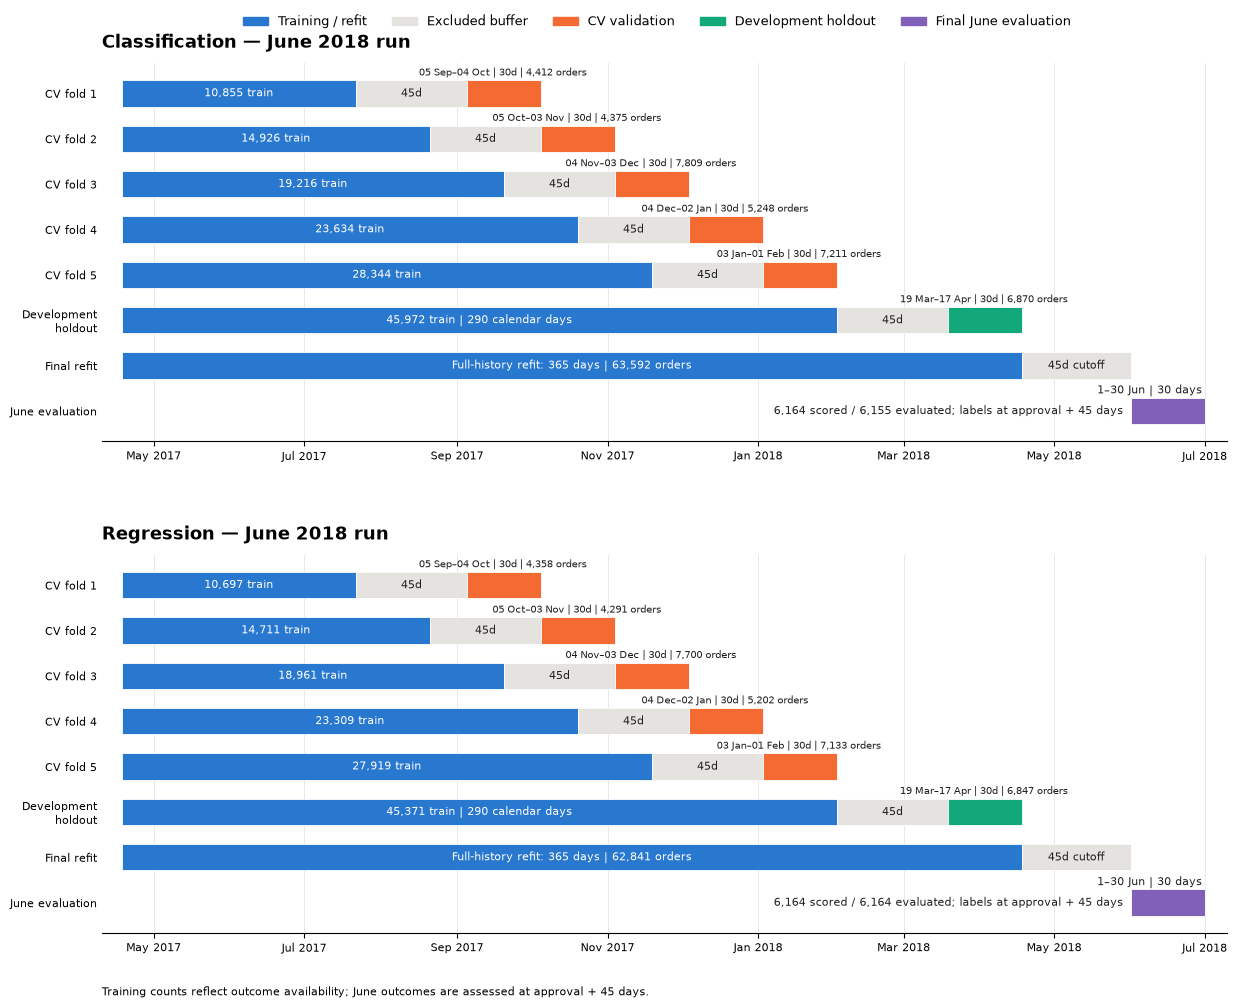

In [4]:
# The final refit uses every eligible historical label/target known on the run date.
# June cohort counts are computed from the same order-level feature table and
# label-maturity helpers used in the backtests.
final_refit_classification = classification_history
final_refit_regression = regression_history
june_scored = final_df.loc[
    final_df['order_approved_dt'].between('2018-06-01', '2018-06-30', inclusive='both')
].copy()

classification_stub = june_scored[['order_id', 'order_approved_dt']].copy()
classification_stub['predicted_probability'] = 0.0
june_classification_labels = attach_prediction_labels(
    classification_stub, orders, lookback=LOOKBACK
)
june_classification_evaluated = int(june_classification_labels['actual_label'].notna().sum())

june_regression_labels = attach_regression_actuals(
    june_scored[['order_id', 'order_approved_dt']], orders, waiting_period=WAITING_PERIOD
)
june_regression_evaluated = int(june_regression_labels['actual_target'].notna().sum())

classification_timeline = {
    'development_train': classification_train,
    'development_holdout': classification_holdout,
    'cv_folds': classification_folds,
    'final_refit': final_refit_classification,
    'june_scored': june_scored,
    'june_evaluated': june_classification_evaluated,
    'window_start': window_start,
    'window_end': window_end,
}
regression_timeline = {
    'development_train': regression_train,
    'development_holdout': regression_holdout,
    'cv_folds': regression_folds,
    'final_refit': final_refit_regression,
    'june_scored': june_scored,
    'june_evaluated': june_regression_evaluated,
    'window_start': window_start,
    'window_end': window_end,
}

fig = plot_validation_timelines(
    classification_timeline,
    regression_timeline,
    FIGURE_PATH,
    n_splits=N_CV_FOLDS,
    validation_days=VALIDATION_DAYS,
    gap_days=GAP_DAYS,
    holdout_gap_days=HOLDOUT_GAP_DAYS,
    test_days=TEST_DAYS,
    inference_start='2018-06-01',
    inference_end='2018-06-30',
)
print(f'Figure saved to {FIGURE_PATH.resolve()}')
print('Suggested report title: Chronological CV, development holdout and June 2018 inference workflow')


Calendar date labels are derived from the eligible order rows and split indices. Counts reflect classification label availability and regression target eligibility. The final refit spans the full historical window ending 45 days before June inference; the internal development gap does not remove those orders from the final fit once their outcomes are known.